In [ ]:
!pip install pandas matplotlib numpy

In [33]:
!pip install scikit-learn

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ------------ --------------------------- 2.6/8.1 MB 16.7 MB/s eta 0:00:01
   ------------------------------------ --- 7.3/8.1 MB 20.2 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 18.4 MB/s  0:00:00
   ---------------------------------------- 0.0/39.4 MB ? eta -:--:--
   ---- ----------------------------------- 4.2/39.4 MB 21.4 MB/s eta 0:00:02
   -------- ------------------------------- 8.7/39.4 MB 21.9 MB/s eta 0:00:02
   ------------- -------------------------- 13.6/39.4 MB 22.5 MB/s eta 0:00:02
   ------------------ --------------------- 18.4/39.4 MB 22.6 MB/s eta 0:00:01
   ------------------------ --------------- 24.1/39.4 MB 23.6 MB/s eta 0:00:01
   ----------------------------- ---------- 29.4/39.4 MB 23.9 MB/s eta 0:00:01
   ----------------------------------- ---- 34.9/39.4 MB 24.3 MB/s eta 0:00:01
   ---------------------------------------  39.1/39.4 MB 23.9 MB/s eta 0:00:01
   

In [101]:
import pandas as pd
import matplotlib as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display

In [102]:
initial_load = pd.read_csv("C:/Users/MyYoga/Downloads/online_retail/Copy of Online Retail.csv")

In [103]:
df = pd.DataFrame(initial_load).copy()

In [104]:
df
#541,909 rows

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01/12/2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01/12/2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01/12/2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01/12/2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01/12/2010 08:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,09/12/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,09/12/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,09/12/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,09/12/2011 12:50,4.15,12680.0,France


In [105]:
# Finding out all the diffrent data types will help us decide if any columns need to be dropped or changed
print(df.dtypes)
# Customer ID is coming up as a float, which should never be the case- most likely happening due to missing values

InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object


In [106]:
print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

        InvoiceDate  UnitPrice  CustomerID         Country  
0  01/12/2010 08:26       2.55     17850.0  United Kingdom  
1  01/12/2010 08:26       3.39     17850.0  United Kingdom  
2  01/12/2010 08:26       2.75     17850.0  United Kingdom  
3  01/12/2010 08:26       3.39     17850.0  United Kingdom  
4  01/12/2010 08:26       3.39     17850.0  United Kingdom  


In [107]:
print(df.isna().sum())
# Description nulls can be ignored because it's not likely we will be using this column for our clustering analysis, customer ID is a tricky one, for now I will drop and see how it changes

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [108]:
print(df['Country'].unique())
# large dataset

['United Kingdom' 'France' 'Australia' 'Netherlands' 'Germany' 'Norway'
 'EIRE' 'Switzerland' 'Spain' 'Poland' 'Portugal' 'Italy' 'Belgium'
 'Lithuania' 'Japan' 'Iceland' 'Channel Islands' 'Denmark' 'Cyprus'
 'Sweden' 'Austria' 'Israel' 'Finland' 'Bahrain' 'Greece' 'Hong Kong'
 'Singapore' 'Lebanon' 'United Arab Emirates' 'Saudi Arabia'
 'Czech Republic' 'Canada' 'Unspecified' 'Brazil' 'USA'
 'European Community' 'Malta' 'RSA']


In [109]:
df.groupby("Country")["CustomerID"].nunique().sort_values(ascending=False)

Country
United Kingdom          3950
Germany                   95
France                    87
Spain                     31
Belgium                   25
Switzerland               21
Portugal                  19
Italy                     15
Finland                   12
Austria                   11
Norway                    10
Channel Islands            9
Netherlands                9
Australia                  9
Denmark                    9
Cyprus                     8
Japan                      8
Sweden                     8
Poland                     6
Unspecified                4
Canada                     4
USA                        4
Greece                     4
Israel                     4
EIRE                       3
Bahrain                    2
Malta                      2
United Arab Emirates       2
Brazil                     1
Czech Republic             1
Saudi Arabia               1
Lebanon                    1
Iceland                    1
European Community         1
Lithua

In [110]:
no_nulldf = df.dropna(subset=["CustomerID"]).copy()
no_nulldf

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01/12/2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01/12/2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01/12/2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01/12/2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01/12/2010 08:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,09/12/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,09/12/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,09/12/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,09/12/2011 12:50,4.15,12680.0,France


In [111]:
# after dropping the customer ID nulls, is any other categorical column skewed from before?
no_nulldf.groupby("Country")["CustomerID"].nunique().sort_values(ascending=False)
# All the unique values look the same, so no unknown customer IDs are skewed towards one country.

Country
United Kingdom          3950
Germany                   95
France                    87
Spain                     31
Belgium                   25
Switzerland               21
Portugal                  19
Italy                     15
Finland                   12
Austria                   11
Norway                    10
Australia                  9
Denmark                    9
Netherlands                9
Channel Islands            9
Japan                      8
Sweden                     8
Cyprus                     8
Poland                     6
Unspecified                4
USA                        4
Canada                     4
Israel                     4
Greece                     4
EIRE                       3
United Arab Emirates       2
Bahrain                    2
Malta                      2
Brazil                     1
Lebanon                    1
Iceland                    1
Czech Republic             1
European Community         1
Saudi Arabia               1
RSA   

In [112]:
# Converting the invoice date into a date time data type
no_nulldf["InvoiceDate"] = pd.to_datetime(no_nulldf["InvoiceDate"], dayfirst=True)
#Invoice dates were provided in day-first format (DD/MM/YYYY), consistent with the UK origin of the dataset. Dates were explicitly parsed using dayfirst=True to avoid misinterpretation of ambiguous dates
no_nulldf["InvoiceDate"].isna().sum()

np.int64(0)

In [113]:
# converting customer ID into int now that nulls have been dropped
no_nulldf["CustomerID"] = no_nulldf["CustomerID"].astype(int)
no_nulldf

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France


In [114]:
print(no_nulldf.dtypes)

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID              int64
Country                object
dtype: object


In [115]:
# Filtering out negatives in quantity and unit price (very common in this dataset, was written in the description, plus I noticed some immediatly when I opened the dataset)
df = no_nulldf
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)].copy()
df #397884 rows

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France


In [116]:
# checking to see if the cleaning has worked
(df["Quantity"] <= 0).sum(), (df["UnitPrice"] <= 0).sum()
# both come out as 0, both have been filtered appropriately

(np.int64(0), np.int64(0))

In [117]:
# Invoice numbers starting with 'C' are cancelled orders, my previous filtering should most likely already remove these rows, but a sense check is always good
df["cancelled"] = df["InvoiceNo"].str.startswith("C")
df["cancelled"].value_counts()
# As expected the previous filtering step has already removed all the C policies, there are 397k FALSE rows, ie- 397k do not begin with C

cancelled
False    397884
Name: count, dtype: int64

In [118]:
# Basic EDA to look at extreme values and know where to clip the data to get the most accurate clustering results (for the monetary factor)
df[["Quantity", "UnitPrice"]].describe(percentiles=[0.05,0.95, 0.99])

,Quantity,UnitPrice
count,397884.000000,397884.000000
mean,12.988238,3.116488
std,179.331775,22.097877
min,1.000000,0.001000
5%,1.000000,0.420000
50%,6.000000,1.950000
95%,36.000000,8.500000
99%,120.000000,14.950000
max,80995.000000,8142.750000


# Discussions in order to justify where to cut the data #
The jump from 99% to MAX is incredibly high for both quantity and unit price /
It would make the most sense to cut these out as the max values just seem like one-off orders and would hugely skew our results

In [132]:
# --------------------------------
# 1) Create line-level total spend
# --------------------------------
df["LineTotal"] = df["Quantity"] * df["UnitPrice"]

# --------------------------------
# 2) Define reference date
# --------------------------------
ref_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

# --------------------------------
# 3) Build RFM table (customer level)
# --------------------------------
rfm = (
    df.groupby("CustomerID")
      .agg(
          Recency=("InvoiceDate", lambda x: (ref_date - x.max()).days),
          Frequency=("InvoiceNo", "nunique"),
          Monetary=("LineTotal", "sum")
      )
      .reset_index()
)

# --------------------------------
# 4) Quick sanity checks
# --------------------------------
print(rfm.head())
print(rfm.describe(percentiles=[0.05,0.95, 0.99]))

   CustomerID  Recency  Frequency  Monetary
0       12346      326          1  77183.60
1       12347        2          7   4310.00
2       12348       75          4   1797.24
3       12349       19          1   1757.55
4       12350      310          1    334.40
         CustomerID      Recency    Frequency       Monetary
count   4338.000000  4338.000000  4338.000000    4338.000000
mean   15300.408022    92.536422     4.272015    2054.266460
std     1721.808492   100.014169     7.697998    8989.230441
min    12346.000000     1.000000     1.000000       3.750000
5%     12614.850000     3.000000     1.000000     112.309500
50%    15299.500000    51.000000     2.000000     674.485000
95%    17984.150000   312.000000    13.000000    5841.843000
99%    18225.630000   369.000000    30.000000   19880.995700
max    18287.000000   374.000000   209.000000  280206.020000


#### Both Frequency and Monetary have a large jump from the 99% percentile to Max ####
##### Will do some extra exploring on these outliers and decide wheter to cap both columns prior to transformation below #####

In [121]:
# Exploring the outliers from before in more detail at the RFM level
rfm["Monetary"].describe(percentiles=[0.95, 0.99])
#99th percentile is over 10x smaller than the max, huge outlier causing a massive right skew, must be capped.

count      4338.000000
mean       2054.266460
std        8989.230441
min           3.750000
50%         674.485000
95%        5841.843000
99%       19880.995700
max      280206.020000
Name: Monetary, dtype: float64

In [122]:
rfm["Monetary"].skew()
# Large positive (right) skew

np.float64(19.32495323682082)

In [144]:
# Creating new clipped solumn instead of reqriting original to see the change
p99 = rfm["Monetary"].quantile(0.99)

rfm["Monetary_clip99"] = rfm["Monetary"].clip(upper=p99)

In [145]:
rfm[["Monetary", "Monetary_clip99"]].describe()

,Monetary,Monetary_clip99
count,4338.000000,4338.000000
mean,2054.266460,1598.576105
std,8989.230441,2797.829264
min,3.750000,3.750000
25%,307.415000,307.415000
50%,674.485000,674.485000
75%,1661.740000,1661.740000
max,280206.020000,19880.995700


<Axes: >

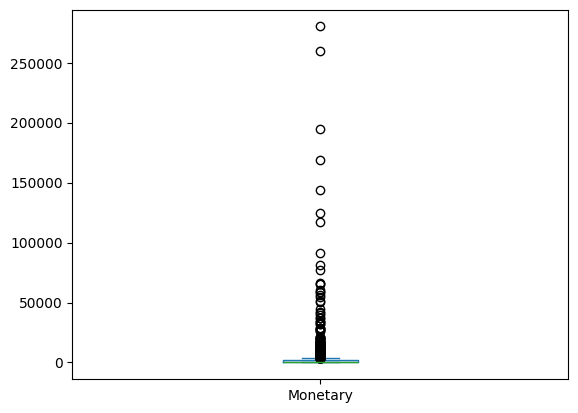

In [161]:
rfm['Monetary'].plot.box()

<Axes: >

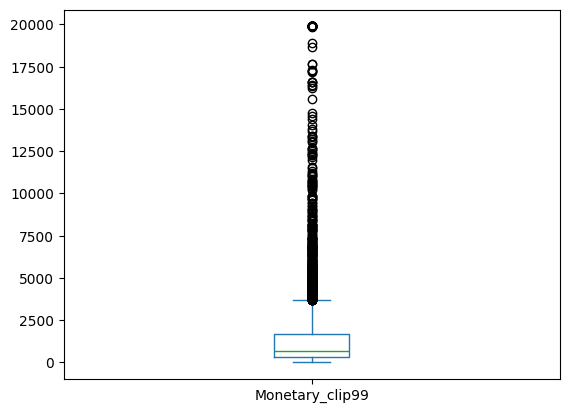

In [162]:
rfm['Monetary_clip99'].plot.box()

In [146]:
# How many customers were affected?
(rfm["Monetary"] > p99).sum()
# 44 were a part of the top 1% causing this skew, most likely wholesalers/ big batch orders, for this excercise it is best to remove them.

np.int64(44)

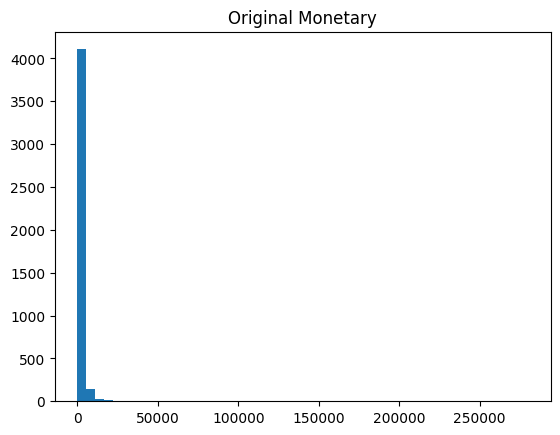

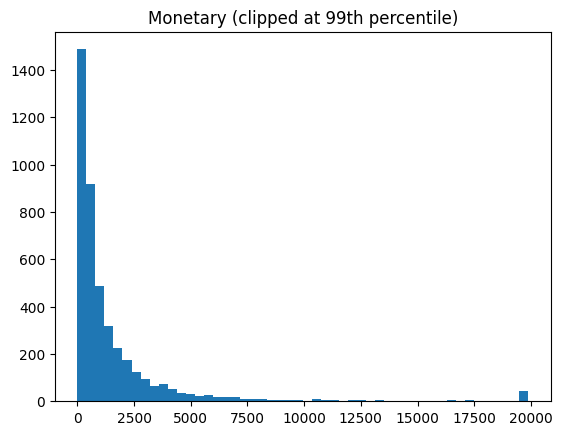

In [152]:
# Visually showing the change between 99% and 100%
plt.hist(rfm["Monetary"], bins=50)
plt.title("Original Monetary")
plt.show()

plt.hist(rfm["Monetary_clip99"], bins=50)
plt.title("Monetary (clipped at 99th percentile)")
plt.show()
# HUGE gaps are being prevented, can see the tail shrinking.

In [129]:
# Checking how skew changes after log transformation for og monetary and clipped monetary
rfm["Monetary_log"] = np.log1p(rfm["Monetary"])
rfm["Monetary_log_clipped"] = np.log1p(rfm["Monetary_clip99"])

In [130]:
rfm[["Monetary", "Monetary_clip99", "Monetary_log","Monetary_log_clipped"]].skew()
# The clipped monetary factor which was then log trasnformed has the lowest skew, therfore this value was picked to cluster with.

Monetary                19.324953
Monetary_clip99          4.307847
Monetary_log             0.393553
Monetary_log_clipped     0.200573
dtype: float64

Doing Frequency now

In [133]:
# Exploring the outliers from before in more detail at the RFM level
rfm["Frequency"].describe(percentiles=[0.95, 0.99])
# It has almost a 7x jump in the final percentile, probably causing a lot of right skew

count    4338.000000
mean        4.272015
std         7.697998
min         1.000000
50%         2.000000
95%        13.000000
99%        30.000000
max       209.000000
Name: Frequency, dtype: float64

In [135]:
rfm['Frequency'].skew()
# Large right skew, very assymetric data, best to cap.

np.float64(12.067030826322075)

In [136]:
# Creating new clipped solumn instead of reqriting original to see the change
p99 = rfm["Frequency"].quantile(0.99)

rfm["Frequency_clip99"] = rfm["Frequency"].clip(upper=p99)

In [137]:
rfm[["Frequency", "Frequency_clip99"]].describe()

,Frequency,Frequency_clip99
count,4338.000000,4338.000000
mean,4.272015,4.008760
std,7.697998,4.863497
min,1.000000,1.000000
25%,1.000000,1.000000
50%,2.000000,2.000000
75%,5.000000,5.000000
max,209.000000,30.000000


<Axes: >

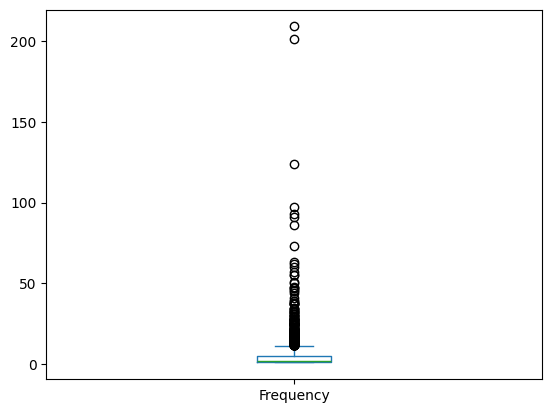

In [160]:
rfm["Frequency"].plot.box()

<Axes: >

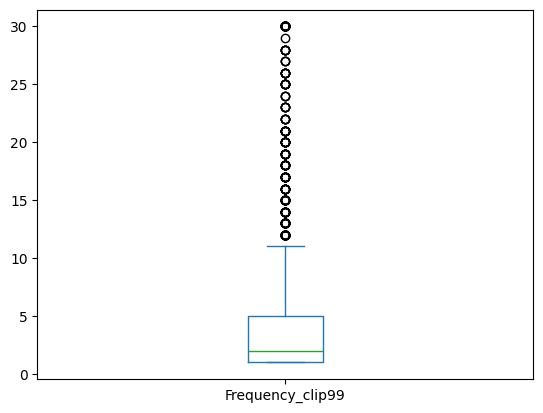

In [157]:
rfm["Frequency_clip99"].plot.box()

In [138]:
# How many customers were affected?
(rfm["Frequency"] > p99).sum()
# 42 customers are a part of the top 1%, not large enough to justify leaving them unclipped

np.int64(42)

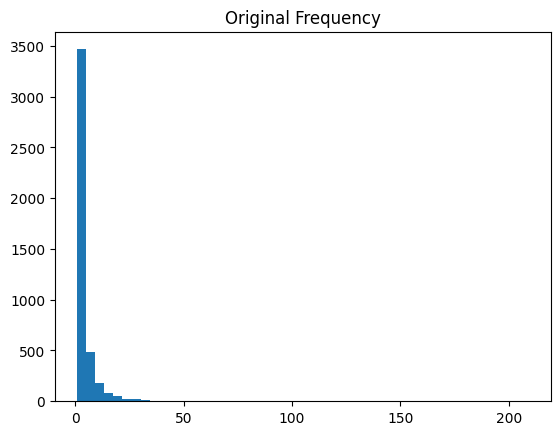

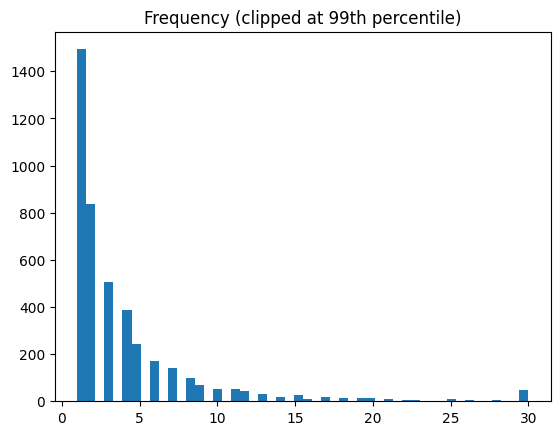

In [153]:
# Visually showing the change between 99% and 100%
plt.hist(rfm["Frequency"], bins=50)
plt.title("Original Frequency")
plt.show()

plt.hist(rfm["Frequency_clip99"], bins=50)
plt.title("Frequency (clipped at 99th percentile)")
plt.show()
# Data flows more smoothly, not conitnous because frequency is a discrete measure and the dataset is not big enough for a large enough spread most likely.

In [154]:
# Checking how skew changes after log transformation for og monetary and clipped monetary
rfm["Frequency_log"] = np.log1p(rfm["Frequency"])
rfm["Frequency_log_clipped"] = np.log1p(rfm["Frequency_clip99"])

In [155]:
rfm[["Frequency", "Frequency_clip99", "Frequency_log","Frequency_log_clipped"]].skew()
# The clipped frequency factor which was then log trasnformed has the lowest skew, therfore this value was picked to cluster with.

Frequency                12.067031
Frequency_clip99          3.052054
Frequency_log             1.208652
Frequency_log_clipped     1.004264
dtype: float64

In [163]:
# 1) Copy RFM to avoid overwriting
# -------------------------------
rfm_t = rfm.copy()

# -------------------------------
# 2) Light transformations
# -------------------------------
# Reduce skew (common for Frequency and Monetary)
rfm_t["Frequency"] = np.log1p(rfm_t["Frequency_log_clipped"])
rfm_t["Monetary"]  = np.log1p(rfm_t["Monetary_clip99"])


# (Explore: also try clipping Monetary before log, or leaving Recency untransformed)

# -------------------------------
# 3) Select features for clustering
# -------------------------------
X = rfm_t[["Recency", "Frequency", "Monetary"]]

# -------------------------------
# 4) Standardize (required for K-means)
# -------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [164]:
X.describe()           # before scaling

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,0.813887,6.584490
std,100.014169,0.265036,1.227978
min,1.000000,0.526589,1.558145
25%,18.000000,0.526589,5.731446
50%,51.000000,0.741276,6.515431
75%,142.000000,1.026672,7.416222
max,374.000000,1.489299,9.897570


In [165]:
pd.DataFrame(X_scaled).describe()  # after scaling, normalised data which K means expects

,0,1,2
count,4.338000e+03,4.338000e+03,4.338000e+03
mean,2.702618e-17,-5.339717e-16,3.341418e-16
std,1.000115e+00,1.000115e+00,1.000115e+00
min,-9.153401e-01,-1.084121e+00,-4.093659e+00
25%,-7.453445e-01,-1.084121e+00,-6.947530e-01
50%,-4.153533e-01,-2.739975e-01,-5.624421e-02
75%,4.946227e-01,8.029448e-01,6.773965e-01
max,2.814561e+00,2.548671e+00,2.698306e+00


In [166]:
# X_scaled should be your standardized matrix from RFM (shape: n_customers x 3)
# e.g., X_scaled = scaler.fit_transform(rfm_t[["Recency","Frequency","Monetary"]])

ks = range(2, 11)  # explore a small, reasonable range
inertias = []
silhouettes = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

# Minimal numeric output (so you can decide without plotting)
for k, inertia, sil in zip(ks, inertias, silhouettes):
    print(f"k={k:2d}  inertia={inertia:,.2f}  silhouette={sil:.3f}")

# Pick k by:
# - elbow in inertia (big drops then flatten)
# - AND a relatively high silhouette (not necessarily the absolute max)


k= 2  inertia=6,503.94  silhouette=0.421
k= 3  inertia=4,108.53  silhouette=0.415
k= 4  inertia=3,115.51  silhouette=0.374
k= 5  inertia=2,700.35  silhouette=0.368
k= 6  inertia=2,317.58  silhouette=0.341
k= 7  inertia=2,092.55  silhouette=0.328
k= 8  inertia=1,906.83  silhouette=0.322
k= 9  inertia=1,743.36  silhouette=0.303
k=10  inertia=1,634.08  silhouette=0.308


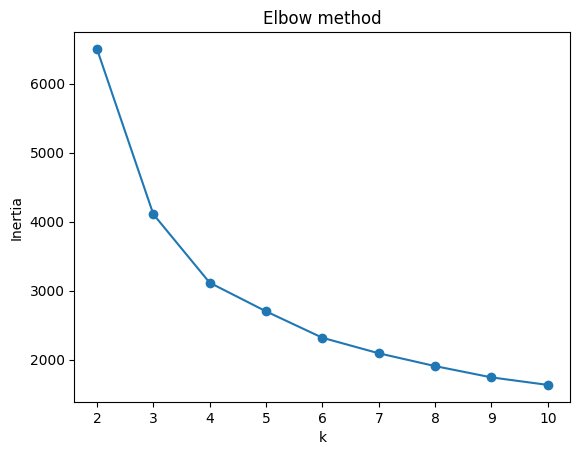

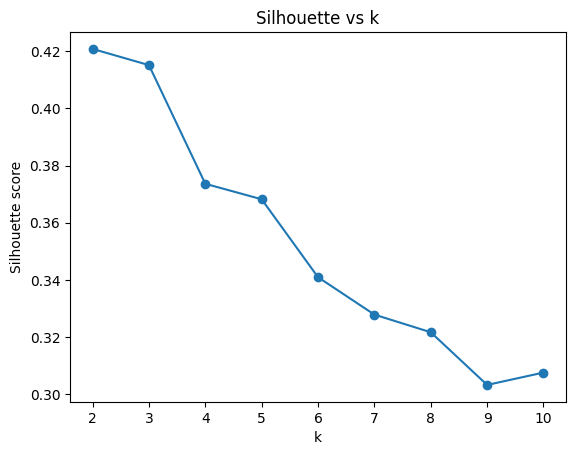

In [167]:
plt.plot(list(ks), inertias, marker="o")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow method")
plt.show()

plt.plot(list(ks), silhouettes, marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.title("Silhouette vs k")
plt.show()

In [168]:
k = 4  # or 3 if you prefer
km = KMeans(n_clusters=k, random_state=42, n_init="auto")

rfm["Cluster"] = km.fit_predict(X_scaled)

In [169]:
rfm["Cluster"].value_counts().sort_index()

Cluster
0    1095
1     871
2     897
3    1475
Name: count, dtype: int64

In [170]:
cluster_profile = (
    rfm
    .groupby("Cluster")
    .agg(
        Customers=("CustomerID", "count"),
        Recency_mean=("Recency", "mean"),
        Frequency_mean=("Frequency", "mean"),
        Monetary_mean=("Monetary", "mean"),
        Recency_median=("Recency", "median"),
        Frequency_median=("Frequency", "median"),
        Monetary_median=("Monetary", "median"),
    )
)

cluster_profile

,Customers,Recency_mean,Frequency_mean,Monetary_mean,Recency_median,Frequency_median,Monetary_median
Cluster,,,,,,,
0,1095,58.987215,1.299543,324.900439,52.0,1.0,289.99
1,871,23.345580,12.507463,7371.783777,12.0,9.0,3539.37
2,897,263.424749,1.325530,465.845775,261.0,1.0,292.47
3,1475,54.376949,3.407458,1164.037012,38.0,3.0,982.07


In [171]:
overall = rfm[["Recency", "Frequency", "Monetary"]].median()
overall

Recency       51.000
Frequency      2.000
Monetary     674.485
dtype: float64

In [172]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

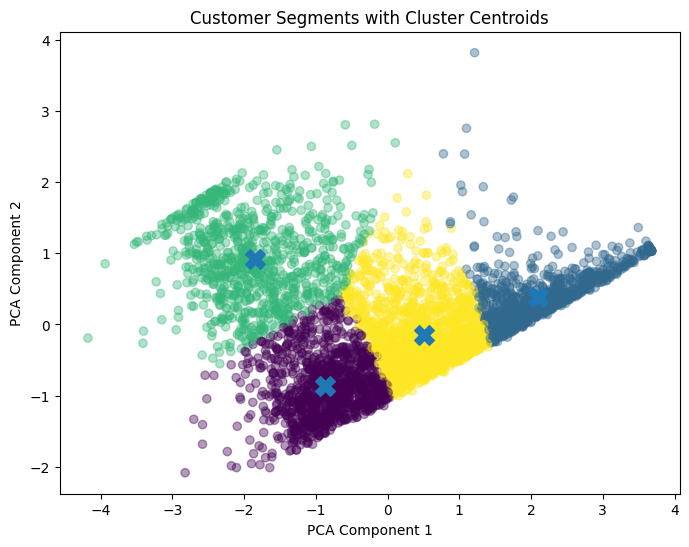

In [173]:
centroids_pca = pca.transform(km.cluster_centers_)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=rfm["Cluster"], alpha=0.4)
plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    marker="X",
    s=200
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Customer Segments with Cluster Centroids")
plt.show()

In [174]:
def _greedy_match(prev_pts: np.ndarray, curr_pts: np.ndarray):
    if prev_pts.size == 0 or curr_pts.size == 0:
        return []
    d2 = ((prev_pts[:, None, :] - curr_pts[None, :, :]) ** 2).sum(axis=2)
    pairs = [(i, j, d2[i, j]) for i in range(d2.shape[0]) for j in range(d2.shape[1])]
    pairs.sort(key=lambda x: x[2])

    used_prev, used_curr, matches = set(), set(), []
    for i, j, _ in pairs:
        if i in used_prev or j in used_curr:
            continue
        matches.append((i, j))
        used_prev.add(i); used_curr.add(j)
        if len(used_prev) == d2.shape[0] or len(used_curr) == d2.shape[1]:
            break
    return matches

def animate_kmeans_pca_to_gif(
    X_scaled,
    gif_path="kmeans_pca_k_sweep.gif",
    ks=range(2, 11),
    fps=0.25,
    n_init="auto",
    random_state=42,
    point_alpha=0.35,
    point_size=14,
    centroid_size=220
):
    # PCA fixed once so axes don't shift between frames
    pca = PCA(n_components=2, random_state=random_state)
    X_pca = pca.fit_transform(X_scaled)

    ks = list(ks)
    if any(k < 2 for k in ks):
        raise ValueError("All k must be >= 2 for KMeans.")

    max_k = max(ks)

    frames = []
    for k in ks:
        km = KMeans(n_clusters=k, random_state=random_state, n_init=n_init)
        labels = km.fit_predict(X_scaled)
        centroids_pca = pca.transform(km.cluster_centers_)
        frames.append({"k": k, "labels": labels, "centroids_pca": centroids_pca})

    fig, ax = plt.subplots(figsize=(9, 7))
    ax.set_xlabel("PCA Component 1")
    ax.set_ylabel("PCA Component 2")
    title = ax.set_title("K-means customer segments (PCA view)")

    # Lock limits
    pad = 0.05
    x_min, x_max = X_pca[:, 0].min(), X_pca[:, 0].max()
    y_min, y_max = X_pca[:, 1].min(), X_pca[:, 1].max()
    dx, dy = (x_max - x_min), (y_max - y_min)
    ax.set_xlim(x_min - pad * dx, x_max + pad * dx)
    ax.set_ylim(y_min - pad * dy, y_max + pad * dy)

    # IMPORTANT: Fix colormap scaling so new cluster IDs get new colors
    sc_points = ax.scatter(
        X_pca[:, 0], X_pca[:, 1],
        c=frames[0]["labels"],
        s=point_size, alpha=point_alpha,
        vmin=-0.5, vmax=max_k - 0.5
    )

    # Color centroids by their (current) cluster id
    sc_centroids = ax.scatter(
        frames[0]["centroids_pca"][:, 0],
        frames[0]["centroids_pca"][:, 1],
        marker="X", s=centroid_size,
        c=np.arange(frames[0]["centroids_pca"].shape[0]),
        vmin=-0.5, vmax=max_k - 0.5
    )

    tracks = [[tuple(pt)] for pt in frames[0]["centroids_pca"]]
    line_artists = []

    def _clear_lines():
        nonlocal line_artists
        for ln in line_artists:
            ln.remove()
        line_artists = []

    def _draw_tracks():
        nonlocal line_artists
        _clear_lines()
        for tr in tracks:
            if len(tr) < 2:
                continue
            xs = [p[0] for p in tr]
            ys = [p[1] for p in tr]
            (ln,) = ax.plot(xs, ys, linewidth=2, alpha=0.8)  # default colors
            line_artists.append(ln)

    def update(i):
        nonlocal tracks
        fr = frames[i]
        k = fr["k"]
        labels = fr["labels"]
        centroids = fr["centroids_pca"]

        sc_points.set_array(labels.astype(float))

        sc_centroids.set_offsets(centroids)
        sc_centroids.set_array(np.arange(len(centroids)).astype(float))

        title.set_text(f"K-means customer segments (PCA view) — k={k}")

        if i == 0:
            tracks = [[tuple(pt)] for pt in centroids]
        else:
            prev_centroids = frames[i - 1]["centroids_pca"]
            matches = _greedy_match(prev_centroids, centroids)

            new_tracks = [[tuple(pt)] for pt in centroids]
            for i_prev, j_curr in matches:
                if i_prev < len(tracks):
                    carried = tracks[i_prev].copy()
                    carried.append(tuple(centroids[j_curr]))
                    new_tracks[j_curr] = carried
            tracks = new_tracks

        _draw_tracks()
        return [sc_points, sc_centroids, title] + line_artists

    anim = FuncAnimation(
        fig, update,
        frames=len(frames),
        interval=int(1000 / fps),
        blit=False,
        repeat=True
    )

    writer = PillowWriter(fps=fps)
    anim.save(gif_path, writer=writer, dpi=120)
    plt.close(fig)
    return gif_path


# --- Run it ---
# Requires: X_scaled already created from your RFM transformations + StandardScaler
gif_file = animate_kmeans_pca_to_gif(
    X_scaled,
    gif_path="kmeans_pca_k_sweep.gif",
    ks=list(range(2, 11)) + list(range(10, 1, -1)),  # up then back down
    fps=0.4
)

gif_file

'kmeans_pca_k_sweep.gif'

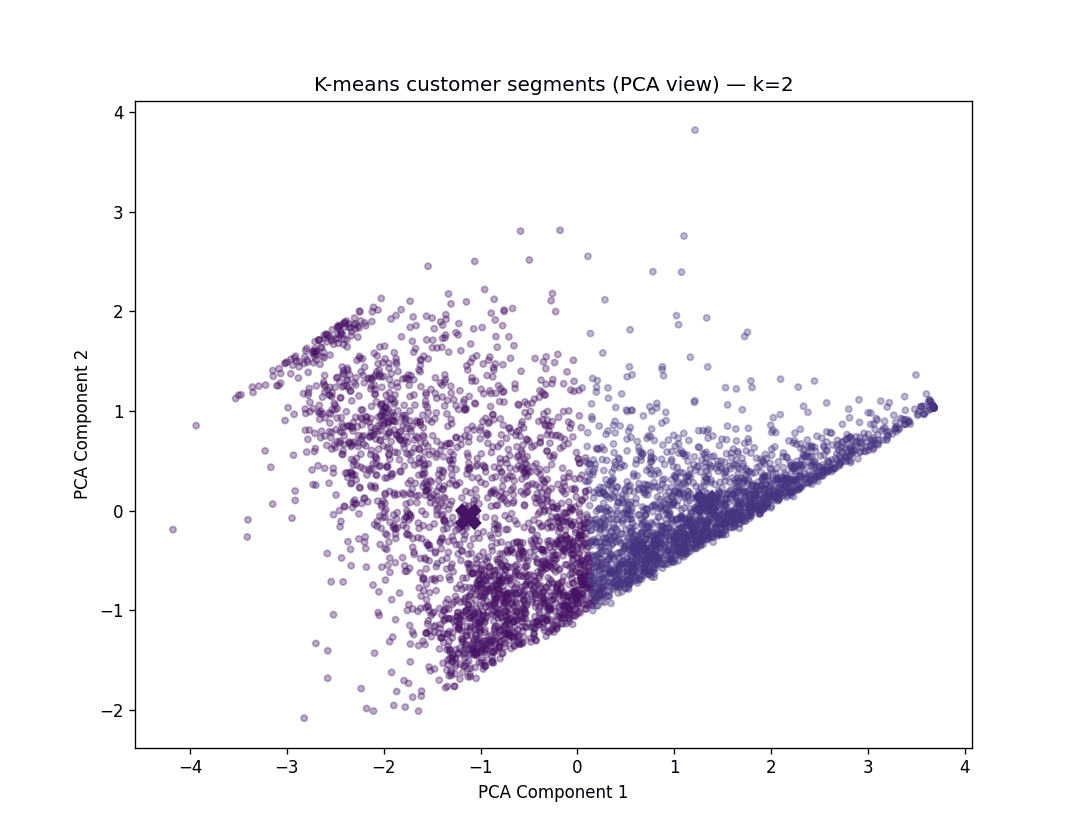

In [175]:
# --- 3) Display the GIF in JupyterLab ---
display(Image(filename="kmeans_pca_k_sweep.gif"))